**Цель работы**
1. Освоить методы обнаружения выбросов на основе статистических
критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом
предметной области.


**Задание:**

В рамках лабораторной работы необходимо выполнить анализ набора данных и
реализовать несколько методов обнаружения аномалий.

Для работы нужно использовать самостоятельно выбранный числовой датасет,
можно продолжить с датасетом, который был выбран в Лабораторной работе №1.


# Задание 1. Загрузка и профилирование данных
1. Загрузить датасет.
2. Выполнить:
- df.info()
- df.describe()
3. Проанализировать:
- наличие пропусков,
- диапазоны значений,
- подозрительные экстремальные значения.

Для двух числовых признаков выполнить визуальный анализ:
1. Построить гистограмму.
2. Построить boxplot.
3. Сделать вывод о возможных выбросах.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/metacritic_games.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')


Размер датасета: 13913 строк, 16 столбцов


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 13913 entries, 0 to 13912
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   13913 non-null  int64  
 1   title                13913 non-null  str    
 2   releaseDate          13884 non-null  str    
 3   rating               11610 non-null  str    
 4   genres               13913 non-null  str    
 5   description          13871 non-null  str    
 6   platforms            13912 non-null  str    
 7   metascore            13912 non-null  float64
 8   metascore_count      13913 non-null  int64  
 9   metascore_sentiment  13912 non-null  str    
 10  userscore            13913 non-null  int64  
 11  userscore_count      13913 non-null  int64  
 12  userscore_sentiment  12440 non-null  str    
 13  platform_metascores  13912 non-null  str    
 14  developer            13904 non-null  str    
 15  publisher            13911 non-null  str    
dt

,id,metascore,metascore_count,userscore,userscore_count
count,1.391300e+04,13912.000000,13913.000000,13913.000000,13913.000000
mean,1.300239e+09,70.580865,25.920506,61.867534,251.236973
std,2.300670e+05,12.281910,20.273256,24.751419,1797.572404
min,1.300000e+09,11.000000,4.000000,0.000000,0.000000
25%,1.300026e+09,64.000000,11.000000,58.000000,10.000000
50%,1.300129e+09,72.000000,19.000000,70.000000,29.000000
75%,1.300480e+09,79.000000,34.000000,78.000000,106.000000
max,1.300713e+09,99.000000,150.000000,100.000000,166719.000000


In [5]:
print("Проанализировать:")

print("="*60)
print("Наличие пропусков")
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")

print("="*60)
print("Диапазоны значений")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col:25} мин: {min_val:10.2f}, макс: {max_val:10.2f}")

print("="*60)
print("Подозрительные экстремальные значения (|Z| > 3)")

for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    threshold = 3 * std_val

    outliers = df[(df[col] < mean_val - threshold) |
                  (df[col] > mean_val + threshold)]

    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Среднее: {mean_val:.2f}")
        print(f"  Std: {std_val:.2f}")
        print(f"  Кол-во выбросов: {len(outliers)}")

        print("  Примеры (max):", outliers[col].nlargest(3).tolist())
        print("  Примеры (min):", outliers[col].nsmallest(3).tolist())

Проанализировать:
Наличие пропусков
id                        0
title                     0
releaseDate              29
rating                 2303
genres                    0
description              42
platforms                 1
metascore                 1
metascore_count           0
metascore_sentiment       1
userscore                 0
userscore_count           0
userscore_sentiment    1473
platform_metascores       1
developer                 9
publisher                 2
dtype: int64

Всего пропусков: 3862
Диапазоны значений
id                        мин: 1300000010.00, макс: 1300713106.00
metascore                 мин:      11.00, макс:      99.00
metascore_count           мин:       4.00, макс:     150.00
userscore                 мин:       0.00, макс:     100.00
userscore_count           мин:       0.00, макс:  166719.00
Подозрительные экстремальные значения (|Z| > 3)

metascore:
  Среднее: 70.58
  Std: 12.28
  Кол-во выбросов: 117
  Примеры (max): [33.0, 33.0, 33.0]
  Прим

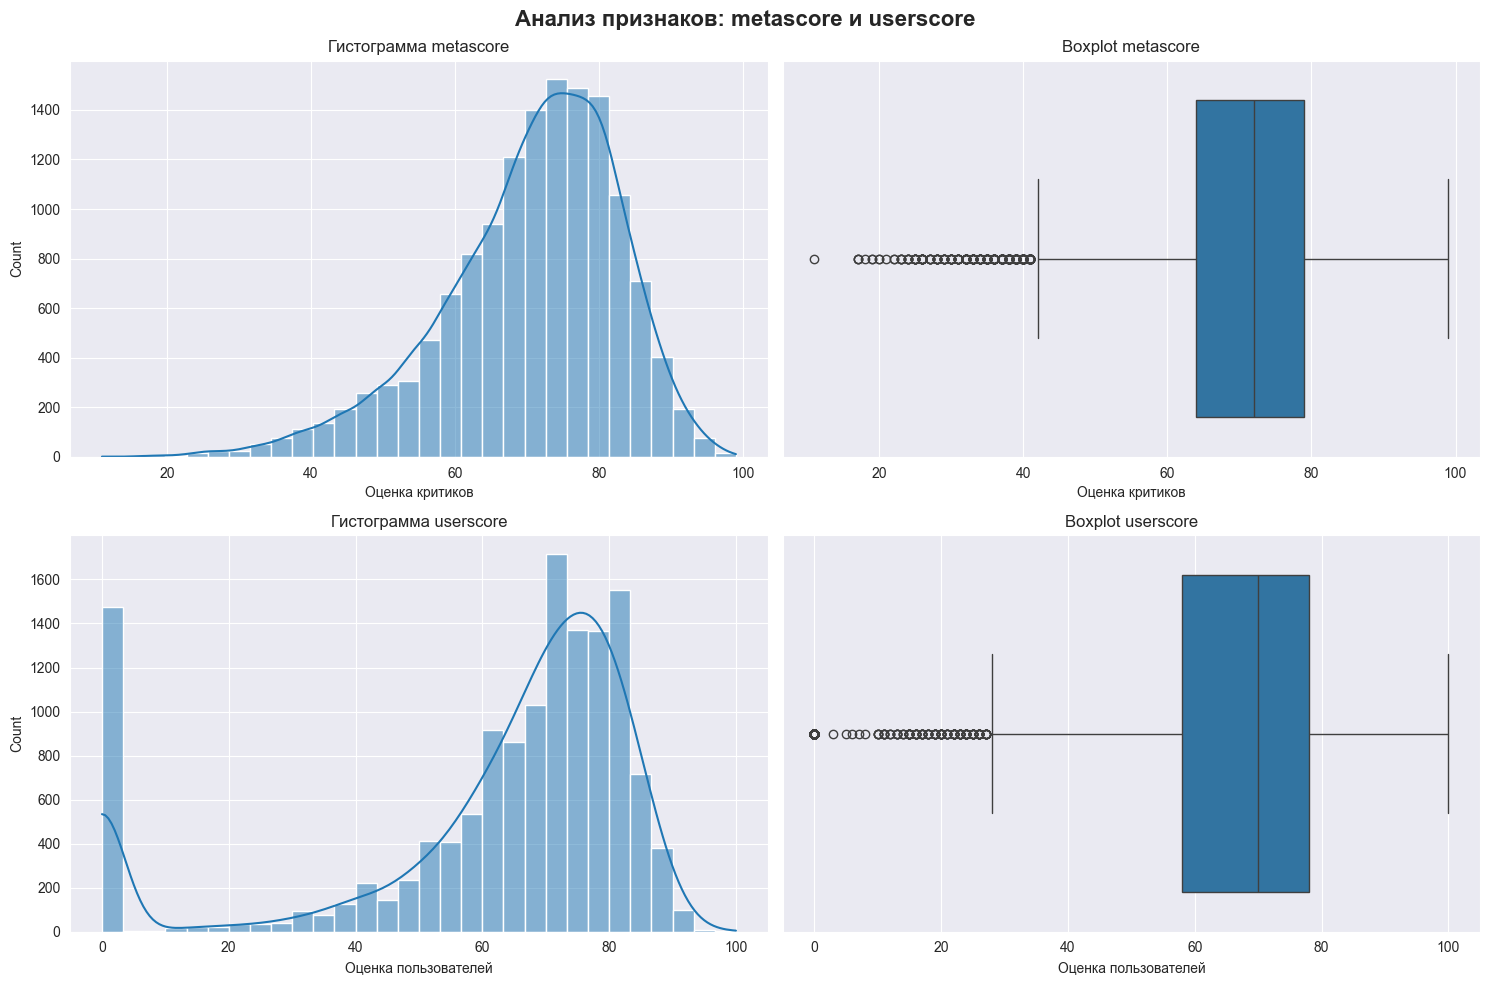

metascore: распределение близко к нормальному
userscore: есть выбросы (значения = 0) - игры без оценок пользователей


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Анализ признаков: metascore и userscore', fontsize=16, fontweight='bold')

# metascore
sns.histplot(df['metascore'].dropna(), kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Гистограмма metascore')
axes[0, 0].set_xlabel('Оценка критиков')

sns.boxplot(x=df['metascore'].dropna(), ax=axes[0, 1])
axes[0, 1].set_title('Boxplot metascore')
axes[0, 1].set_xlabel('Оценка критиков')

# userscore
sns.histplot(df['userscore'].dropna(), kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Гистограмма userscore')
axes[1, 0].set_xlabel('Оценка пользователей')

sns.boxplot(x=df['userscore'].dropna(), ax=axes[1, 1])
axes[1, 1].set_title('Boxplot userscore')
axes[1, 1].set_xlabel('Оценка пользователей')

plt.tight_layout()
plt.show()

print("metascore: распределение близко к нормальному")
print("userscore: есть выбросы (значения = 0) - игры без оценок пользователей")

# Задание 2. Проверка нормальности распределения
Для выбранных признаков:
1. Вычислить описательные характеристики:
- среднее,
- медиану,
- стандартное отклонение,
- коэффициент асимметрии,
- коэффициент эксцесса.


In [7]:
from scipy.stats import skew, kurtosis

for col in ['metascore', 'userscore']:
    print(f"\n{col}:")
    print(f"Среднее: {df[col].mean():.2f}")
    print(f"Медиана: {df[col].median():.2f}")
    print(f"Стандартное отклонение: {df[col].std():.4f}")
    print(f"Коэффициент асимметрии: {skew(df[col]):.4f}")
    print(f"Коэффициент эксцесса: {kurtosis(df[col]):.4f}")


metascore:
Среднее: 70.58
Медиана: 72.00
Стандартное отклонение: 12.2819
Коэффициент асимметрии: nan
Коэффициент эксцесса: nan

userscore:
Среднее: 61.87
Медиана: 70.00
Стандартное отклонение: 24.7514
Коэффициент асимметрии: -1.5662
Коэффициент эксцесса: 1.4443



2. Выполните графический анализ
- Постройте QQ-график.
- Сравните форму распределения с нормальным.


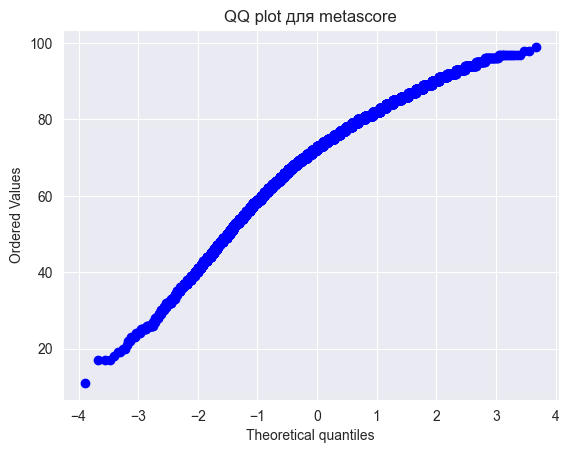

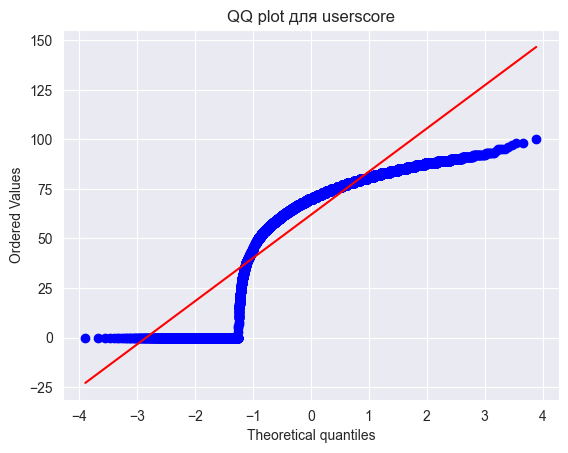

Точки должны лежать на красной прямой
Отклонение от прямой указывает на ненормальность


In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['metascore'], dist="norm", plot=plt)
plt.title("QQ plot для metascore")
plt.show()

stats.probplot(df['userscore'], dist="norm", plot=plt)
plt.title("QQ plot для userscore")
plt.show()

print("Точки должны лежать на красной прямой")
print("Отклонение от прямой указывает на ненормальность")

3. Проверьте нормальность распределения признаков с помощью критерия
Шапиро–Уилка

Сформулируйте гипотезы:
* **H0: выборка подчиняется нормальному распределению**
* **H1: выборка не подчиняется нормальному распределению**

Уровень значимости: α = 0.05
Сделать вывод о принятии или отклонении гипотезы H0

In [10]:
from scipy.stats import shapiro

for col in ['metascore', 'userscore']:
    stat, p = shapiro(df[col].sample(5000))
    print(f"{col}, stat: {stat:.4f}")
    print(f"{col}, p-value: {p:.4f}")

    if p > 0.05:
        print(f"Результат: p > 0.05 → не отвергаем H0")
        print(f"Вывод: данные могут быть нормальными\n")
    else:
        print(f"Результат: p ≤ 0.05 → отвергаем H0")
        print(f"Вывод: данные не являются нормальными\n")

metascore, stat: nan
metascore, p-value: nan
Результат: p ≤ 0.05 → отвергаем H0
Вывод: данные не являются нормальными

userscore, stat: 0.7732
userscore, p-value: 0.0000
Результат: p ≤ 0.05 → отвергаем H0
Вывод: данные не являются нормальными



# Задание 3. Обнаружение выбросов статистическими методами
Для признака, распределение которого ближе к нормальному,

**1. Метод Z-score**
* Рассчитать Z-оценки.
* Определить количество выбросов при |Z| > 3.
* Визуализировать результат.

**2. Метод IQR**
* Вычислить Q1, Q3, IQR.
* Определить границы.
* Найти количество выбросов.
* Сравнить с методом Z-score.

Сделать сравнительный анализ методов.


Анализ признака: 'userscore'
Среднее: 61.87
Стд. откл.: 24.75

Метод Z-score (|Z| > 3)
Количество выбросов: 0


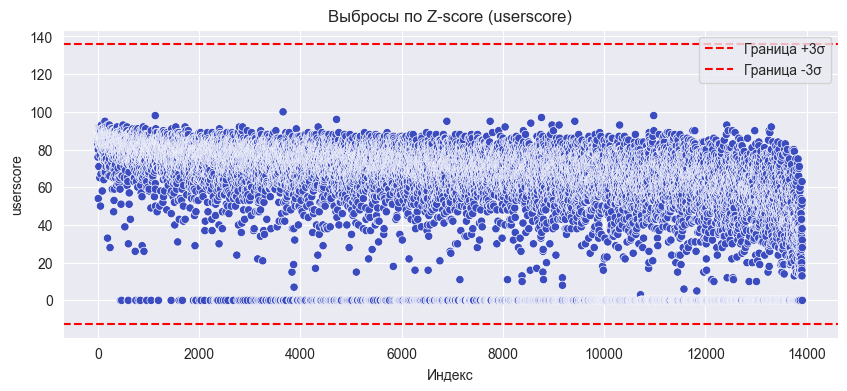

In [12]:
target_col = 'userscore'
data = df[target_col].dropna()

print(f"\nАнализ признака: '{target_col}'")
print(f"Среднее: {data.mean():.2f}")
print(f"Стд. откл.: {data.std():.2f}")

# Метод Z-score
z_scores = np.abs(stats.zscore(data))
outliers_z = data[z_scores > 3]
n_outliers_z = len(outliers_z)

print(f"\nМетод Z-score (|Z| > 3)")
print(f"Количество выбросов: {n_outliers_z}")
if n_outliers_z > 0:
    print(f"Примеры выбросов: {outliers_z.head().values}")

# Визуализация Z-score
plt.figure(figsize=(10, 4))
sns.scatterplot(x=np.arange(len(data)), y=data, c=z_scores > 3, cmap='coolwarm', legend=False)
plt.title(f'Выбросы по Z-score ({target_col})')
plt.xlabel('Индекс')
plt.ylabel(target_col)
plt.axhline(y=data.mean() + 3*data.std(), color='r', linestyle='--', label='Граница +3σ')
plt.axhline(y=data.mean() - 3*data.std(), color='r', linestyle='--', label='Граница -3σ')
plt.legend()
plt.show()


Метод IQR
Q1: 58.00, Q3: 78.00, IQR: 20.00
Нижняя граница: 28.00
Верхняя граница: 108.00
Количество выбросов: 1620
Примеры выбросов: [ 0  0  0  0 26]


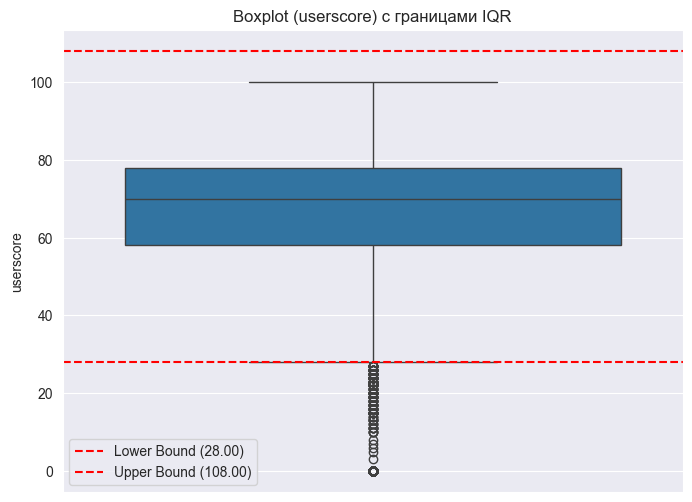

Z-score нашел: 0 выбросов
IQR нашел:     1620 выбросов
Вывод: IQR более чувствителен к выбросам в хвостах распределения.
Z-score лучше работает при нормальном распределении, a IQR более универсален


In [13]:
# Метод IQR
target_col = 'userscore'  # Ваш признак
data = df[target_col].dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]
n_outliers_iqr = len(outliers_iqr)

print(f"\nМетод IQR")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {n_outliers_iqr}")
if n_outliers_iqr > 0:
    print(f"Примеры выбросов: {outliers_iqr.head().values}")

# Визуализация IQR
plt.figure(figsize=(8, 6))
sns.boxplot(y=data)
plt.title(f'Boxplot ({target_col}) с границами IQR')
plt.ylabel(target_col)
plt.axhline(y=lower_bound, color='r', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
plt.axhline(y=upper_bound, color='r', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')
plt.legend()
plt.show()

# Сравнительный анализ
print(f"Z-score нашел: {n_outliers_z} выбросов")
print(f"IQR нашел:     {n_outliers_iqr} выбросов")
if n_outliers_z == 0 and n_outliers_iqr == 0:
    print("Вывод: Оба метода не обнаружили выбросов.")
elif n_outliers_iqr > n_outliers_z:
    print("Вывод: IQR более чувствителен к выбросам в хвостах распределения.")
else:
    print("Вывод: Z-score выявил больше экстремальных значений.")

print("Z-score лучше работает при нормальном распределении, a IQR более универсален")

# Задание 4. Метод локальной плотности
Аномалия - это объект, находящийся в области низкой плотности по сравнению
с окружающими объектами.

Если для типичной точки характерно наличие большого числа близких соседей,
то у аномальной точки:
* мало соседей,
* либо расстояние до соседей значительно больше среднего.

Таким образом, мера аномальности может быть построена на основе:
* расстояний до k ближайших соседей,
* оценки локальной плотности.

В качестве метрик расстояния используйте Евклидово и Манхэттенское
расстояния. Предварительно выполните масштабирование признаков (StandardScaler
или MinMaxScaler).


Анализ для k=5
Порог (95-й перцентиль среднего расстояния): 0.3037
Количество аномалий: 622 (5.0%)


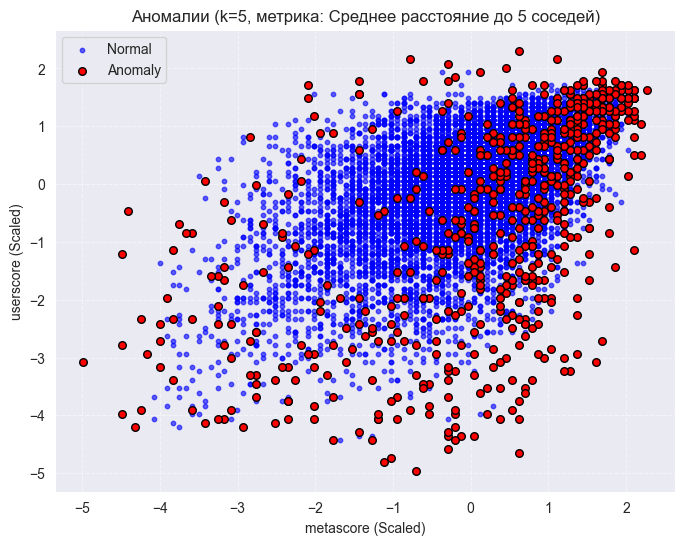


Анализ для k=7
Порог (95-й перцентиль среднего расстояния): 0.3570
Количество аномалий: 622 (5.0%)


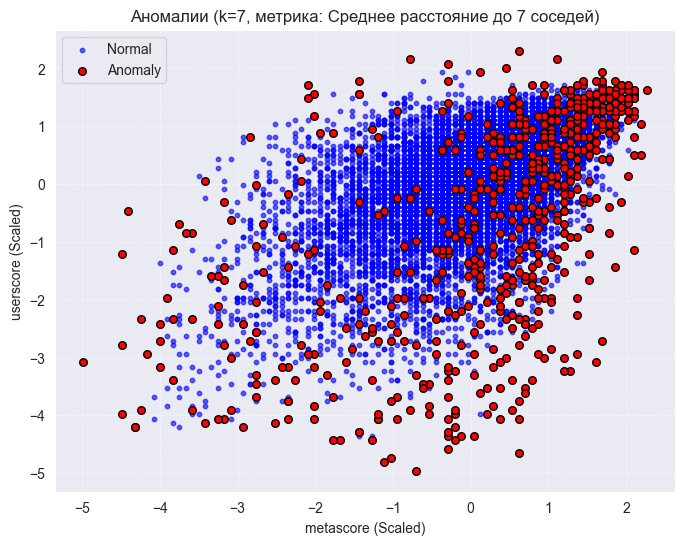


Анализ для k=9
Порог (95-й перцентиль среднего расстояния): 0.3961
Количество аномалий: 622 (5.0%)


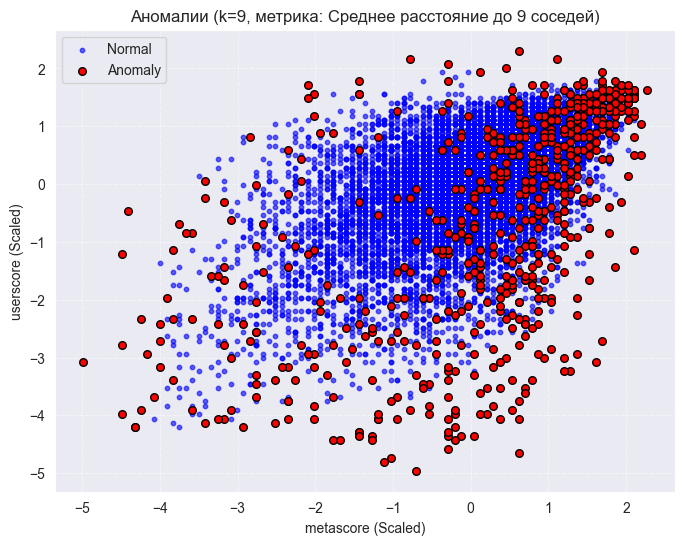


Анализ для k=10
Порог (95-й перцентиль среднего расстояния): 0.4106
Количество аномалий: 622 (5.0%)


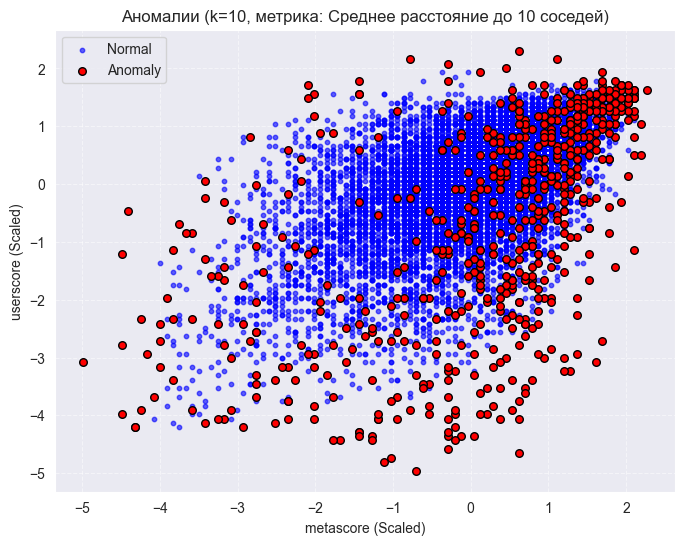


--- Сравнение устойчивости методов при изменении k ---
k     | Кол-во аномалий (Mean Dist) | Кол-во аномалий (Density)
------------------------------------------------------------
5     | 622                       | 622                      
7     | 622                       | 622                      
9     | 622                       | 622                      
10    | 622                       | 622                      

Вывод:
1. Метод 'Среднее расстояние до k соседей' более устойчив к шуму, чем просто расстояние до k-го соседа.
2. При увеличении k область влияния каждой точки расширяется, что может приводить к сглаживанию локальных аномалий.
3. Точки, которые являются аномалиями при малых k (локальные выбросы), могут перестать быть аномалиями при больших k, если они находятся рядом с другим кластером.
4. Метрика 'Локальная плотность' математически эквивалентна обратному среднему расстоянию, поэтому результаты по количеству аномалий будут идентичны.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Выбираем числовые признаки для анализа локальной плотности
numeric_features = ['metascore', 'userscore', 'metascore_count', 'userscore_count']

# Удаляем пропуски и игры без пользовательских оценок (userscore == 0)
data_multi = df[numeric_features].dropna()
data_multi = data_multi[data_multi['userscore'] > 0].copy()

# Масштабирование признаков (StandardScaler) — обязательно для метрических методов!
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_multi)

def calculate_anomaly_metrics(data, k_values):
    """
    Вычисляет три метрики аномальности для каждого k:
    1. Расстояние до k-го соседа (D_k)
    2. Среднее расстояние до k соседей (Mean_D_k)
    3. Локальная плотность (Density_k = 1 / Mean_D_k)
    """
    results = {}

    for k in k_values:
        # Инициализация модели KNN (евклидово расстояние по умолчанию)
        neigh = NearestNeighbors(n_neighbors=k, metric='euclidean')
        neigh.fit(data)

        # Получаем расстояния до всех k соседей
        distances, indices = neigh.kneighbors(data)

        # Расстояние до k-го соседа (последний элемент в строке)
        dist_kth = distances[:, -1]

        # Среднее расстояние до k соседей (исключаем 0-е расстояние до самой точки)
        mean_dist_k = np.mean(distances, axis=1)

        # Локальная плотность (обратная величина среднему расстоянию)
        density_k = 1 / (mean_dist_k + 1e-5)

        results[k] = {
            'dist_kth': dist_kth,
            'mean_dist_k': mean_dist_k,
            'density_k': density_k
        }

    return results

k_list = [5, 7, 9, 10]
metrics = calculate_anomaly_metrics(scaled_data, k_list)

# Анализ и Визуализация
# Используем "Среднее расстояние до k соседей" как основную метрику аномальности
for k in k_list:
    print(f"\nАнализ для k={k}")

    # Используем среднее расстояние как меру аномальности
    anomaly_metric = metrics[k]['mean_dist_k']

    # Порог для верхних 5%
    threshold = np.percentile(anomaly_metric, 95)

    # Маска аномалий
    is_anomaly = anomaly_metric > threshold
    n_anomalies = np.sum(is_anomaly)

    print(f"Порог (95-й перцентиль среднего расстояния): {threshold:.4f}")
    print(f"Количество аномалий: {n_anomalies} ({n_anomalies/len(anomaly_metric)*100:.1f}%)")

    # Визуализация для первых двух признаков (metascore, userscore)
    x_idx = 0
    y_idx = 1

    plt.figure(figsize=(8, 6))

    # Нормальные точки
    plt.scatter(scaled_data[~is_anomaly, x_idx],
                scaled_data[~is_anomaly, y_idx],
                c='blue', label='Normal', s=10, alpha=0.6)

    # Аномалии
    plt.scatter(scaled_data[is_anomaly, x_idx],
                scaled_data[is_anomaly, y_idx],
                c='red', label='Anomaly', s=30, edgecolors='black')

    plt.title(f'Аномалии (k={k}, метрика: Среднее расстояние до {k} соседей)')
    plt.xlabel(f'{numeric_features[x_idx]} (Scaled)')
    plt.ylabel(f'{numeric_features[y_idx]} (Scaled)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Анализ устойчивости метода при изменении k
print("\n--- Сравнение устойчивости методов при изменении k ---")
print(f"{'k':<5} | {'Кол-во аномалий (Mean Dist)':<25} | {'Кол-во аномалий (Density)':<25}")
print("-" * 60)

for k in k_list:
    # Аномалии по среднему расстоянию (чем больше расстояние, тем более аномально)
    mean_dist = metrics[k]['mean_dist_k']
    thresh_mean = np.percentile(mean_dist, 95)
    anom_mean = np.sum(mean_dist > thresh_mean)

    # Аномалии по плотности (чем меньше плотность, тем более аномально)
    density = metrics[k]['density_k']
    thresh_density = np.percentile(density, 5)  # Нижние 5% плотности
    anom_density = np.sum(density < thresh_density)

    print(f"{k:<5} | {anom_mean:<25} | {anom_density:<25}")

print("\nВывод:")
print("1. Метод 'Среднее расстояние до k соседей' более устойчив к шуму, чем просто расстояние до k-го соседа.")
print("2. При увеличении k область влияния каждой точки расширяется, что может приводить к сглаживанию локальных аномалий.")
print("3. Точки, которые являются аномалиями при малых k (локальные выбросы), могут перестать быть аномалиями при больших k, если они находятся рядом с другим кластером.")
print("4. Метрика 'Локальная плотность' математически эквивалентна обратному среднему расстоянию, поэтому результаты по количеству аномалий будут идентичны.")